In [1]:
import os

os.makedirs("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject", exist_ok=True)

In [ ]:
# Create requirements.txt

requirements = """
scikit-learn
streamlit
nltk
numpy
pandas
matplotlib
seaborn
re

"""

with open("/content/drive/MyDrive/NLP_Chatbot_Project/requirements.txt", "w") as f:
    f.write(requirements)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Shape: (4500, 9)
   id            name  years_experience highest_degree  \
0   1     Badhan Shah               9.0      Bachelors   
1   2    Lamia Sarker               2.0        Masters   
2   3    Badhan Molla               2.0      Bachelors   
3   4    Badhan Ahmed               9.0      Bachelors   
4   5  Rasel Siddiqui              10.0      Bachelors   

                                              skills  \
0                                           NLP, GPT   
1  PyTorch, CI/CD, Power BI, Data Visualization, AWS   
2  AWS, Flask, Machine Learning, Model Deployment...   
3  Hadoop, Feature Engineering, Docker Compose, O...   
4     Speech Recognition, Tableau, Azure, TensorFlow   

              current_title  has_portfolio  \
0          Customer Support          False   
1  Administrative Assistant          False   
2  Computer Vision Engineer           True   
3       Data Entry Operator           True   
4          Customer Support          False   

            

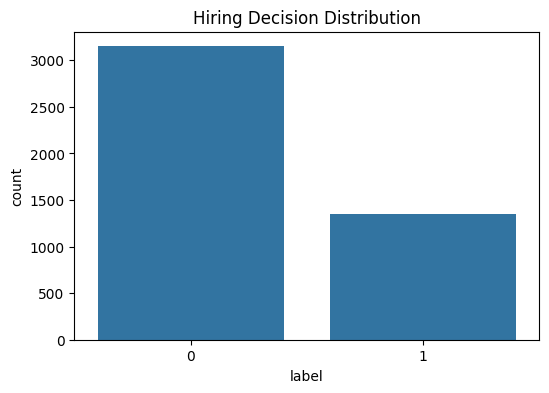

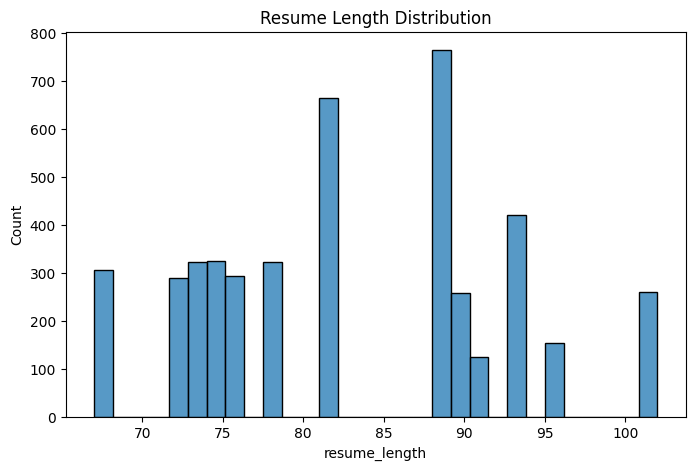

                                            raw_text  \
0  Sales professional with strong communication s...   
1  Sales professional with strong communication s...   
2  Research scientist with strong statistical bac...   
3  Customer support representative with some Exce...   
4  Content creator interested in data science but...   

                                        clean_resume  
0  sales professional strong communication skills...  
1  sales professional strong communication skills...  
2  research scientist strong statistical backgrou...  
3  customer support representative excel skills i...  
4  content creator interested data science lacks ...  

Model Accuracy: 1.0


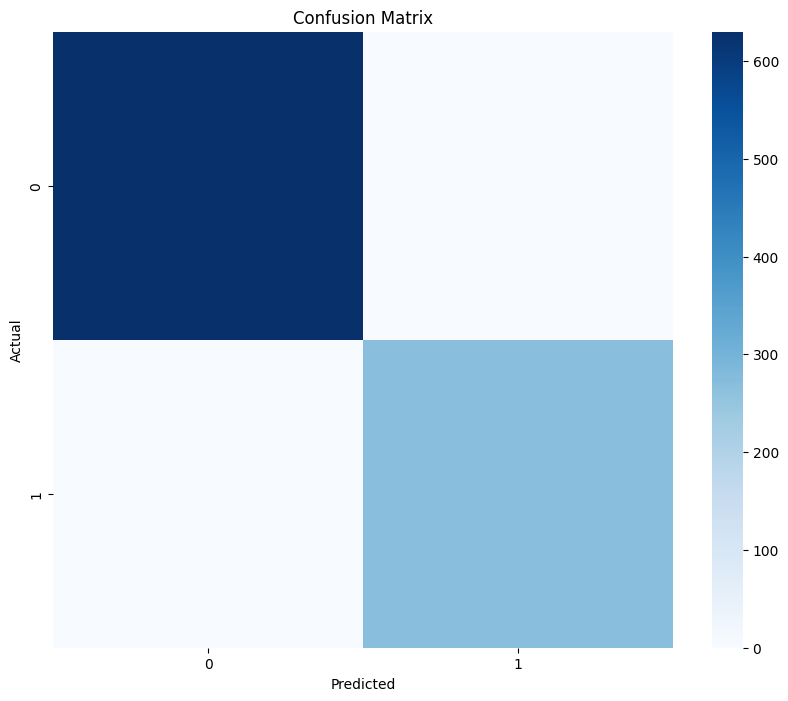


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Predicted Job Category: 0


In [12]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# ==============================
# 2. Load Dataset
# ==============================

df = pd.read_csv("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject/ml_resume_dataset_4500.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Columns assumed:
# Category -> Job role
# Resume -> Resume text

# ==============================
# 3. EDA - Class Distribution
# ==============================

plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Hiring Decision Distribution")
plt.show()

# ==============================
# 4. Resume Length Analysis
# ==============================

df["resume_length"] = df["raw_text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["resume_length"], bins=30)
plt.title("Resume Length Distribution")
plt.show()

# ==============================
# 5. Text Cleaning Function
# ==============================

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

# Apply cleaning

df["clean_resume"] = df["raw_text"].apply(clean_text)

print(df[["raw_text","clean_resume"]].head())

# ==============================
# 6. Feature Engineering
# ==============================

tfidf = TfidfVectorizer(
        max_features=3000,
        ngram_range=(1,2),
        stop_words="english"
)

X = tfidf.fit_transform(df["clean_resume"])

y = df["label"]

# ==============================
# 7. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
)

# ==============================
# 8. Train Model
# ==============================

model = LinearSVC()

model.fit(X_train, y_train)

# ==============================
# 9. Predictions
# ==============================

pred = model.predict(X_test)

import pickle

# save model
pickle.dump(model, open("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject/resume_model.pkl", "wb"))

# save vectorizer
pickle.dump(tfidf, open("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject/vectorizer.pkl", "wb"))

# ==============================
# 10. Model Accuracy
# ==============================

accuracy = accuracy_score(y_test, pred)

print("\nModel Accuracy:", accuracy)

# ==============================
# 11. Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# 12. Classification Report
# ==============================

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# ==============================
# 13. Resume Prediction Function
# ==============================

def predict_resume_category(resume_text):

    cleaned = clean_text(resume_text)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    return prediction

# ==============================
# 14. Example Prediction
# ==============================

sample_resume = """
Experienced data scientist with skills in python, machine learning,
deep learning, pandas, numpy, scikit-learn, and data visualization.
"""

result = predict_resume_category(sample_resume)

print("\nPredicted Job Category:", result)

In [9]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 30.3 MB/s eta 0:00:00


In [16]:
# Create app.py (Streamlit App)

app_code = '''

import streamlit as st
import pickle
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# ==========================
# Load Model
# ==========================

model = pickle.load(open("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject/resume_model.pkl","rb"))
vectorizer = pickle.load(open("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject/vectorizer.pkl","rb"))

# ==========================
# Text Cleaning Function
# ==========================

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

# ==========================
# Prediction Function
# ==========================

def predict_resume(resume_text):

    cleaned = clean_text(resume_text)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]

    return prediction

# ==========================
# Streamlit UI
# ==========================


st.title("AI Resume Screening System")

st.write("Upload or paste a resume to check if the candidate is shortlisted.")

resume_input = st.text_area("Paste Resume Text Here")

if st.button("Predict"):

    if resume_input.strip() == "":
        st.warning("Please enter resume text")

    else:

        result = predict_resume(resume_input)

        if result == 1:
            st.success("Candidate Likely Shortlisted")
        else:
            st.error("Candidate Not Shortlisted")
'''

with open("/content/drive/MyDrive/Intelligent-Resume-screening-system-NLPproject/app.py","w") as f:
    f.write(app_code)

<>:30: SyntaxWarning: invalid escape sequence '\S'
<>:30: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_963/1299233484.py:30: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r"http\S+", "", text)
